# The Visual StoryTeller - Inference

Loads the trained encoder/decoder from `data_and_training.ipynb`, defines `generate_caption()`,
and demonstrates the model on the held-out **test set** — images it never saw during training or
validation — followed by a look at successful and failing examples.

**Requires:** the `models/` folder produced by `data_and_training.ipynb`
(`encoder_best_bleu.pth`, `decoder_best_bleu.pth`, `vocab.pkl`, `config.json`, `test_captions.csv`)
and the same `caption_data/Images` folder, either in the working directory or on Google Drive.

## 1 · Setup

Detects the runtime, mounts Drive on Colab, and locates the `models/` and `caption_data/` folders saved by the training notebook.

In [17]:
import os
import sys
from pathlib import Path

# Runtime detection (used later e.g. to enable Colab's custom widget manager)
IN_COLAB = "google.colab" in sys.modules
IN_KAGGLE = "kaggle_secrets" in sys.modules or os.path.exists("/kaggle/input")

# Folders to search, in order of preference. Anything that doesn't exist is skipped.
SEARCH_ROOTS = [
    Path("."),
    Path("/kaggle/input"),
    Path("/kaggle/working"),
    Path("/content"),
    Path("/content/drive/MyDrive/image_captioning"),
]

def _find_dir_containing(filename_substring, roots):
    """Search roots recursively for a file whose name contains filename_substring,
    and return the directory it lives in."""
    for root in roots:
        if not root.exists():
            continue
        for f in root.rglob("*"):
            if f.is_file() and filename_substring in f.name:
                return f.parent
    return None

def _find_file(filename_substring, roots):
    for root in roots:
        if not root.exists():
            continue
        for f in root.rglob("*"):
            if f.is_file() and filename_substring in f.name:
                return f
    return None

# Locate the model/vocab folder by looking for a distinctive file (vocab.pkl)
MODEL_DIR = _find_dir_containing("vocab", SEARCH_ROOTS) or _find_dir_containing("encoder_best", SEARCH_ROOTS)
if MODEL_DIR is None:
    raise FileNotFoundError(
        "Could not find the trained model artifacts (looked for a vocab*.pkl or "
        "encoder_best*.pth file) under: " + ", ".join(str(r) for r in SEARCH_ROOTS)
    )

# Locate the images folder by looking for an "Images" directory anywhere under the roots
IMG_DIR = None
for root in SEARCH_ROOTS:
    if not root.exists():
        continue
    for d in root.rglob("Images"):
        if d.is_dir():
            IMG_DIR = d
            break
    if IMG_DIR:
        break
if IMG_DIR is None:
    raise FileNotFoundError(
        "Could not find an 'Images' folder under: " + ", ".join(str(r) for r in SEARCH_ROOTS)
    )

print(f"MODEL_DIR: {MODEL_DIR}")
print(f"IMG_DIR:   {IMG_DIR}")

MODEL_DIR: /kaggle/input/datasets/honeygaing/neededfiles
IMG_DIR:   /kaggle/input/datasets/honeygaing/caption-data-zip/Images


## 2 · Load Model Architecture & Weights

Rebuilds the same `EncoderCNN` / `CaptionDecoder` classes used in training, then loads the best-BLEU checkpoint, the vocabulary, and `config.json`.

In [18]:

import math
import pickle
import json

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as tvm

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class Vocabulary:
    PAD, UNK, SOS, EOS = "<pad>", "<unk>", "<sos>", "<eos>"

    def __init__(self, min_freq=2):
        self.min_freq = min_freq
        self.stoi, self.itos = {}, {}

    def build(self, captions):
        from collections import Counter
        cnt   = Counter(w for cap in captions for w in cap.split())
        words = [self.PAD, self.UNK, self.SOS, self.EOS] + [
            w for w, f in cnt.most_common() if f >= self.min_freq
        ]
        self.stoi = {w: i for i, w in enumerate(words)}
        self.itos = {i: w for w, i in self.stoi.items()}

    def __len__(self): return len(self.stoi)

    def encode(self, caption):
        unk = self.stoi[self.UNK]
        return ([self.stoi[self.SOS]]
                + [self.stoi.get(w, unk) for w in caption.split()]
                + [self.stoi[self.EOS]])

    def decode(self, ids, skip_special=True):
        sp = {self.PAD, self.UNK, self.SOS, self.EOS}
        return " ".join(
            self.itos[i] for i in ids
            if not skip_special or self.itos.get(i, self.UNK) not in sp
        )


class EncoderCNN(nn.Module):
    """EfficientNet-B4 backbone; only the last three blocks are fine-tuned."""

    def __init__(self, proj_dim=512, dropout=0.1):
        super().__init__()
        try:
            base = tvm.efficientnet_b4(weights=tvm.EfficientNet_B4_Weights.IMAGENET1K_V1)
        except Exception as _e:
            _msg = str(_e).lower()
            if any(k in _msg for k in ("name resolution", "urlopen", "gaierror", "connection")):
                raise RuntimeError(
                    "\n\nCannot download EfficientNet-B4 weights — internet is disabled.\n"
                    "  Kaggle : right panel -> Settings -> Internet -> ON  (session will restart)\n"
                    "  Colab  : Runtime -> Change runtime type -> confirm, then re-run\n"
                    "After enabling internet, re-run all cells from the top.\n"
                ) from None
            raise
        self.features = base.features
        self.dropout  = nn.Dropout2d(dropout)

        for p in self.features.parameters():
            p.requires_grad = False
        for blk_idx in [6, 7, 8]:
            for p in self.features[blk_idx].parameters():
                p.requires_grad = True

        self.proj_final = nn.Sequential(
            nn.Conv2d(1792, proj_dim, 1, bias=False),
            nn.BatchNorm2d(proj_dim), nn.ReLU(inplace=True),
        )

    def forward(self, x):
        feat = self.features(x)
        feat = self.dropout(feat)
        f = self.proj_final(feat)
        B, C, H, W = f.shape
        return f.view(B, C, H * W).permute(0, 2, 1)   # (B, H*W, proj_dim)


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=200, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.dropout(self.pe[:, :x.size(1)])


class TransformerDecoderLayer(nn.Module):
    """Standard self-attn + cross-attn decoder block."""

    def __init__(self, d_model, n_heads, ffn_dim, dropout=0.1):
        super().__init__()
        self.self_attn  = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.cross_attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.ff = nn.Sequential(
            nn.Linear(d_model, ffn_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(ffn_dim, d_model), nn.Dropout(dropout),
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)

    def forward(self, tgt, memory, tgt_mask=None, tgt_key_padding_mask=None):
        sa, _ = self.self_attn(tgt, tgt, tgt, attn_mask=tgt_mask,
                               key_padding_mask=tgt_key_padding_mask, need_weights=False)
        tgt = self.norm1(tgt + sa)
        ca, _ = self.cross_attn(tgt, memory, memory, need_weights=False)
        tgt = self.norm2(tgt + ca)
        tgt = self.norm3(tgt + self.ff(tgt))
        return tgt


class CaptionDecoder(nn.Module):
    def __init__(self, vocab_size, d_model=512, n_heads=8, n_layers=2,
                 ffn_dim=2048, max_len=52, dropout=0.3):
        super().__init__()
        self.embed   = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_enc = PositionalEncoding(d_model, max_len + 2, dropout)
        self.layers  = nn.ModuleList([
            TransformerDecoderLayer(d_model, n_heads, ffn_dim, dropout=dropout)
            for _ in range(n_layers)
        ])
        self.fc_out  = nn.Linear(d_model, vocab_size)
        self.d_model = d_model
        self.n_heads = n_heads
        nn.init.xavier_uniform_(self.embed.weight)
        self.fc_out.weight = self.embed.weight   # weight tying
        nn.init.zeros_(self.fc_out.bias)

    @staticmethod
    def _causal_mask(sz, device):
        return torch.triu(torch.ones(sz, sz, device=device), diagonal=1).bool()

    def forward(self, memory, captions):
        tgt_tokens = captions[:, :-1]
        tgt_emb    = self.pos_enc(self.embed(tgt_tokens) * math.sqrt(self.d_model))
        T_tgt      = tgt_emb.size(1)
        causal     = self._causal_mask(T_tgt, memory.device)
        pad_mask   = (tgt_tokens == 0)   # True = ignore (PyTorch MHA convention)
        h = tgt_emb
        for layer in self.layers:
            h = layer(h, memory, tgt_mask=causal, tgt_key_padding_mask=pad_mask)
        return self.fc_out(h)

    @torch.no_grad()
    def generate_beam(self, memory, vocab, beam_width=3, max_len=48, length_penalty=0.7):
        self.eval()
        sos = vocab.stoi[vocab.SOS]; eos = vocab.stoi[vocab.EOS]
        pad = vocab.stoi[vocab.PAD]; unk = vocab.stoi[vocab.UNK]
        device = memory.device

        def _norm(raw, length):
            return raw / (((5 + length) / 6) ** length_penalty)

        beams = [(0.0, [sos])]
        done  = []
        for _ in range(max_len):
            if not beams:
                break
            next_beams = []
            for score, tokens in beams:
                if tokens[-1] == eos:
                    done.append((score, tokens))
                    continue
                ids  = torch.tensor([tokens], dtype=torch.long, device=device)
                emb  = self.pos_enc(self.embed(ids) * math.sqrt(self.d_model))
                mask = self._causal_mask(emb.size(1), device)
                h = emb
                for layer in self.layers:
                    h = layer(h, memory, tgt_mask=mask)
                logits   = self.fc_out(h[:, -1, :])
                log_prob = F.log_softmax(logits, dim=-1).squeeze(0)
                top_lp, top_id = log_prob.topk(beam_width)
                for tlp, tid in zip(top_lp.tolist(), top_id.tolist()):
                    next_beams.append((score + tlp, tokens + [tid]))
            if not next_beams:
                break
            next_beams.sort(key=lambda x: _norm(x[0], len(x[1])), reverse=True)
            beams = next_beams[:beam_width]
        if not done:
            done = [(b[0], b[1]) for b in beams]
        _, best = max(done, key=lambda x: _norm(x[0], len(x[1])))
        skip = {sos, eos, pad, unk}
        return [vocab.itos[i] for i in best if i not in skip]


In [19]:
def _find_in_model_dir(substring, exact_name=None):
    """Find a file in MODEL_DIR. Tries an exact plain filename first (e.g.
    'vocab.pkl'), then falls back to a substring search so old-style duplicate
    downloads like 'vocab (1).pkl' still work if they're ever present."""
    if exact_name is not None:
        exact = MODEL_DIR / exact_name
        if exact.exists():
            return exact
    matches = [f for f in MODEL_DIR.glob("*") if substring in f.name]
    if not matches:
        return None
    matches.sort(key=lambda f: len(f.name))
    return matches[0]

vocab_path = _find_in_model_dir("vocab", exact_name="vocab.pkl")
config_path = _find_in_model_dir("config", exact_name="config.json")
if vocab_path is None or config_path is None:
    raise FileNotFoundError(
        f"Could not find vocab*.pkl or config*.json in {MODEL_DIR}. "
        f"Files present: {[f.name for f in MODEL_DIR.glob('*')]}"
    )

with open(vocab_path, "rb") as f:
    vocab = pickle.load(f)
with open(config_path) as f:
    cfg = json.load(f)
print(f"Loaded vocab from: {vocab_path.name}")
print(f"Loaded config from: {config_path.name}")
print(f"Vocab size: {len(vocab):,}")
print(f"Config: {cfg}")

encoder = EncoderCNN(proj_dim=cfg["proj_dim"], dropout=cfg["dropout"]).to(DEVICE)
decoder = CaptionDecoder(
    vocab_size=cfg["vocab_size"], d_model=cfg["embed_size"], n_heads=cfg["n_heads"],
    n_layers=cfg["n_layers"], ffn_dim=cfg["ffn_dim"], max_len=cfg["max_seq_len"],
).to(DEVICE)


_ckpt_candidates = [
    ("best_bleu",     "encoder_best_bleu", "decoder_best_bleu", "encoder_best_bleu.pth", "decoder_best_bleu.pth"),
    ("best_val_loss", "encoder_best",      "decoder_best",      "encoder_best.pth",      "decoder_best.pth"),
    ("final",         "encoder_final",     "decoder_final",     "encoder_final.pth",     "decoder_final.pth"),
]
_enc_ckpt = _dec_ckpt = _ckpt_kind = None
for kind, enc_sub, dec_sub, enc_name, dec_name in _ckpt_candidates:
    enc_p = _find_in_model_dir(enc_sub, exact_name=enc_name)
    dec_p = _find_in_model_dir(dec_sub, exact_name=dec_name)
  
    if kind == "best_val_loss":
        enc_p = next((f for f in MODEL_DIR.glob("*") if enc_sub in f.name and "bleu" not in f.name), None)
        dec_p = next((f for f in MODEL_DIR.glob("*") if dec_sub in f.name and "bleu" not in f.name), None)
    if enc_p and dec_p:
        _enc_ckpt, _dec_ckpt, _ckpt_kind = enc_p, dec_p, kind
        break

if _enc_ckpt is None:
    raise FileNotFoundError(
        f"No matching encoder/decoder checkpoint pair found in {MODEL_DIR} "
        f"(looked for best_bleu, best, then final). "
        f"Files present: {[f.name for f in MODEL_DIR.glob('*')]}"
    )

encoder.load_state_dict(torch.load(_enc_ckpt, map_location=DEVICE, weights_only=True))
decoder.load_state_dict(torch.load(_dec_ckpt, map_location=DEVICE, weights_only=True))
encoder.eval(); decoder.eval()
print(f"Loaded '{_ckpt_kind}' checkpoint: {_enc_ckpt.name} / {_dec_ckpt.name}")

Loaded vocab from: vocab.pkl
Loaded config from: config.json
Vocab size: 3,210
Config: {'encoder': 'efficientnet_b4_singlescale', 'proj_dim': 512, 'decoder': 'transformer', 'embed_size': 512, 'n_heads': 8, 'n_layers': 2, 'ffn_dim': 2048, 'dropout': 0.15, 'vocab_size': 3210, 'max_seq_len': 52, 'beam_width': 5, 'length_penalty': 0.7, 'best_val_loss': 2.967863485870208, 'final_bleu1': 0.6774858320453374, 'final_bleu4': 0.12378821774794929, 'n_gpus': 2, 'grad_accum_steps': 1, 'label_smoothing': 0.05, 'weight_decay': 0.03, 'best_bleu4': 0.12378821774794929}
Loaded 'best_bleu' checkpoint: encoder_best_bleu.pth / decoder_best_bleu.pth


## 3 · `generate_caption`

The required inference function. `model` bundles everything `generate_caption` needs (encoder, decoder, vocab, transform, decoding settings) so the function signature stays exactly `(image_path, model) -> str`.

In [20]:
from PIL import Image
import torchvision.transforms as transforms

MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
inference_transform = transforms.Compose([
    transforms.Resize((380, 380), interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])


class CaptioningModel:
    """Bundles the trained encoder/decoder + vocab so generate_caption only needs one `model` arg."""

    def __init__(self, encoder, decoder, vocab, transform, device,
                 beam_width=5, length_penalty=0.7):
        self.encoder, self.decoder = encoder, decoder
        self.vocab, self.transform = vocab, transform
        self.device = device
        self.beam_width, self.length_penalty = beam_width, length_penalty


model = CaptioningModel(encoder, decoder, vocab, inference_transform, DEVICE,
                         beam_width=cfg.get("beam_width", 5),
                         length_penalty=cfg.get("length_penalty", 0.7))


def generate_caption(image_path: str, model: "CaptioningModel") -> str:
    """Takes a path to an image and returns a generated caption string."""
    img = Image.open(image_path).convert("RGB")
    t = model.transform(img).unsqueeze(0).to(model.device)
    with torch.no_grad():
        feat = model.encoder(t)
        toks = model.decoder.generate_beam(
            feat, model.vocab, model.beam_width, length_penalty=model.length_penalty
        )
    return " ".join(toks)


# quick smoke test on one image from the working directory, if any is present
_probe = next(IMG_DIR.glob("*.jpg"), None)
if _probe:
    print(f"{_probe.name}: {generate_caption(str(_probe), model)}")


3226254560_2f8ac147ea.jpg: a white and brown dog is standing in the snow


## 4 · Demonstration on Unseen Test Images

`test_captions.csv` (written by `data_and_training.ipynb`) lists the images that were held out of both training and validation. `generate_caption` never saw these during training — this is the model's real-world performance.

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter as _C

test_captions_path = _find_in_model_dir("test_captions", exact_name="test_captions.csv")
if test_captions_path is None:
    raise FileNotFoundError(
        f"Could not find test_captions*.csv in {MODEL_DIR}. "
        f"Files present: {[f.name for f in MODEL_DIR.glob('*')]}"
    )

test_df = pd.read_csv(test_captions_path)
test_images = test_df["image"].unique().tolist()
print(f"Loaded test captions from: {test_captions_path.name}")
print(f"Test set: {len(test_images):,} unseen images, {len(test_df):,} reference captions")

def _ng(tok, n):
    return _C(tuple(tok[i:i+n]) for i in range(len(tok)-n+1))

def corpus_bleu(hyps, refs, max_n=4):
    out = {}
    for n in range(1, max_n + 1):
        num = den = 0
        for h, rs in zip(hyps, refs):
            hng  = _ng(h, n)
            rmax = _C()
            for r in rs:
                for ng in (rng := _ng(r, n)):
                    rmax[ng] = max(rmax[ng], rng[ng])
            num += sum(min(c, rmax[ng]) for ng, c in hng.items())
            den += max(1, sum(hng.values()))
        out[f"bleu{n}"] = num / max(den, 1)
    return out

def sentence_bleu4(hyp_str, refs):
    return corpus_bleu([hyp_str.split()], [[r.split() for r in refs]])["bleu4"]

# caption every test image once and score it against its 5 human references
results = []
for name in test_images:
    caption = generate_caption(str(IMG_DIR / name), model)
    refs = test_df[test_df["image"] == name]["caption"].tolist()
    b4 = sentence_bleu4(caption, refs)
    results.append({"image": name, "caption": caption, "refs": refs, "bleu4": b4})

results_df = pd.DataFrame(results)
overall_bleu4 = results_df["bleu4"].mean()
print(f"Mean per-image BLEU-4 on the test set: {overall_bleu4:.3f}")

Loaded test captions from: test_captions.csv
Test set: 100 unseen images, 500 reference captions
Mean per-image BLEU-4 on the test set: 0.094


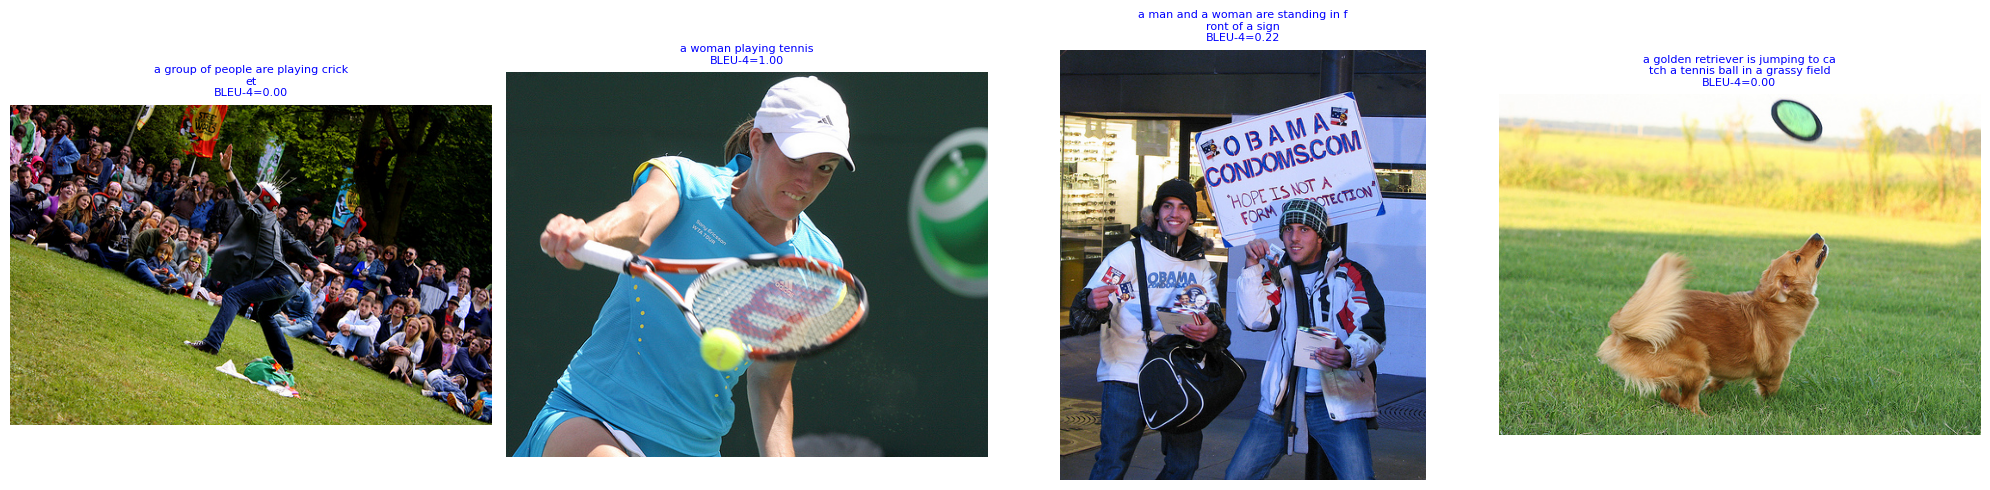

In [26]:

sample = results_df.sample(n=min(4, len(results_df)))
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (_, row) in zip(axes, sample.iterrows()):
    img = Image.open(IMG_DIR / row["image"])
    ax.imshow(img); ax.axis("off")
    cap = row["caption"]
    ax.set_title("\n".join([cap[i:i+35] for i in range(0, min(len(cap), 70), 35)])
                 + f"\nBLEU-4={row['bleu4']:.2f}", fontsize=8, color="blue")
plt.tight_layout(); plt.show()


## 5 · Analysis: Successes vs. Failures

Ranking the test set by per-image BLEU-4 surfaces where the model does well and where it breaks down.

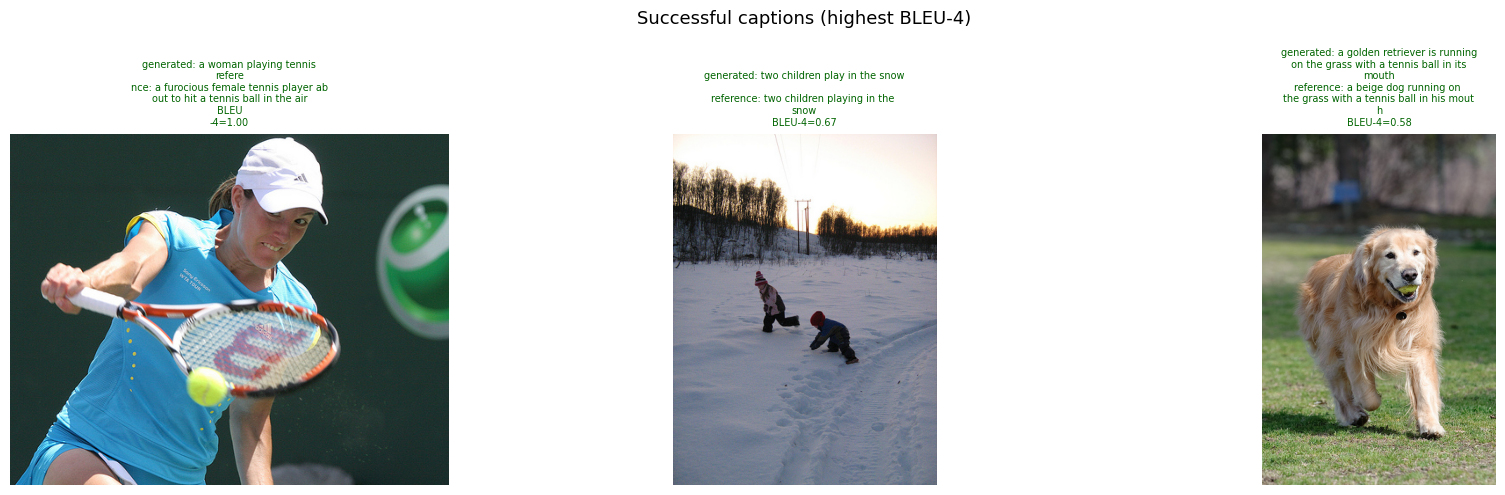

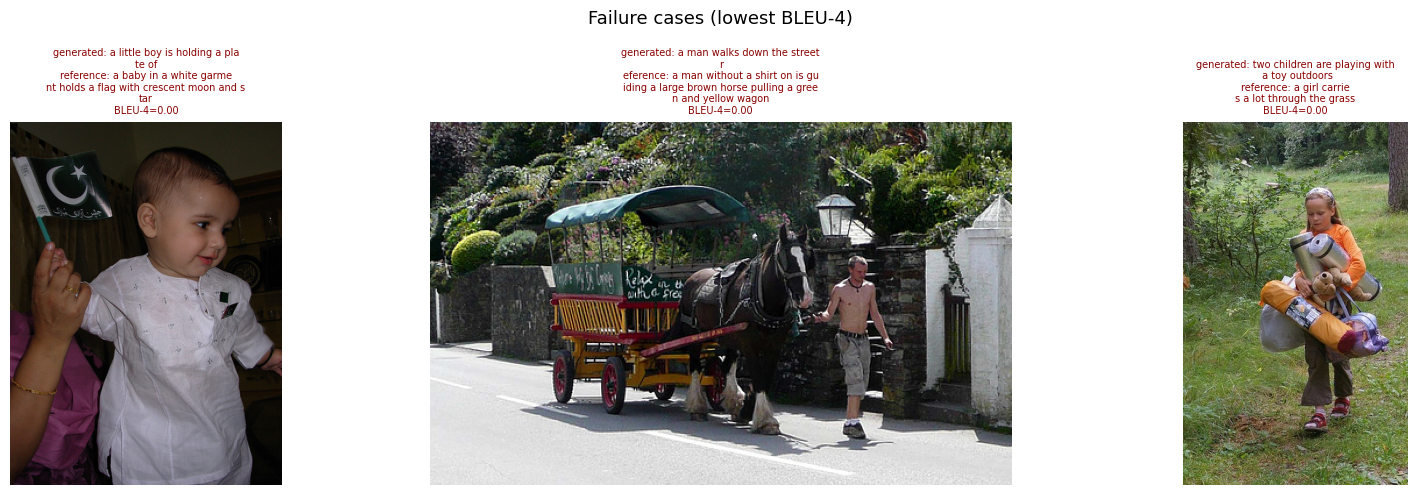


Common failure patterns to look for here: wrong subject/action, missed objects,
generic captions that ignore the specific scene, or repeated/looping phrases.


In [23]:
N = 3
best  = results_df.sort_values("bleu4", ascending=False).head(N)
worst = results_df.sort_values("bleu4", ascending=True).head(N)


def show_group(df, title):
    fig, axes = plt.subplots(1, len(df), figsize=(6 * len(df), 5))
    if len(df) == 1:
        axes = [axes]
    fig.suptitle(title, fontsize=13)
    for ax, (_, row) in zip(axes, df.iterrows()):
        img = Image.open(IMG_DIR / row["image"])
        ax.imshow(img); ax.axis("off")
        ref = row["refs"][0]
        cap = row["caption"]
        label = (f"generated: {cap}\nreference: {ref}\nBLEU-4={row['bleu4']:.2f}")
        ax.set_title("\n".join([label[i:i+40] for i in range(0, len(label), 40)]),
                     fontsize=7, color="darkgreen" if row["bleu4"] >= 0.3 else "darkred")
    plt.tight_layout(); plt.show()


show_group(best, "Successful captions (highest BLEU-4)")
show_group(worst, "Failure cases (lowest BLEU-4)")

print("\nCommon failure patterns to look for here: wrong subject/action, missed objects,")
print("generic captions that ignore the specific scene, or repeated/looping phrases.")


## 6 · Try Your Own Photo

Bonus, not required by the assignment spec (which only asks for `generate_caption` plus a demo/analysis on the provided test set) — but handy for a quick sanity check or a live demo. Upload any image and it's captioned with the same `generate_caption` function used everywhere else in this notebook.


In [24]:
try:
    import ipywidgets as widgets
except ImportError:
    import subprocess, sys as _sys
    subprocess.run([_sys.executable, "-m", "pip", "install", "-q", "ipywidgets"], check=True)
    import ipywidgets as widgets
from IPython.display import display, clear_output
import tempfile

# Colab needs its custom widget manager enabled for FileUpload to render.
if IN_COLAB:
    try:
        from google.colab import output as _colab_output
        _colab_output.enable_custom_widget_manager()
    except Exception:
        pass


def _extract_first_upload(value):
    """FileUpload.value is a dict keyed by filename on ipywidgets 7.x, and a
    tuple/list of dicts on ipywidgets 8.x — handle both."""
    if isinstance(value, dict):
        item = next(iter(value.values()))
        name = item.get("metadata", {}).get("name", "uploaded.jpg")
        content = item["content"]
    else:
        item = value[0]
        name = item.get("name", "uploaded.jpg")
        content = item["content"]
    return name, bytes(content)


uploader = widgets.FileUpload(accept="image/*", multiple=False, description="Upload photo")
_upload_out = widgets.Output()


def _on_upload_change(change):
    with _upload_out:
        clear_output(wait=True)
        if not uploader.value:
            return
        name, content = _extract_first_upload(uploader.value)
        tmp_path = Path(tempfile.gettempdir()) / f"_uploaded{Path(name).suffix or '.jpg'}"
        tmp_path.write_bytes(content)

        caption = generate_caption(str(tmp_path), model)

        img = Image.open(tmp_path).convert("RGB")
        plt.figure(figsize=(5, 5))
        plt.imshow(img); plt.axis("off")
        plt.title(caption, fontsize=10, color="blue", wrap=True)
        plt.show()
        print(f"Caption: {caption}")


uploader.observe(_on_upload_change, names="value")
print("Upload a photo below — the caption renders automatically.")
display(uploader, _upload_out)


Upload a photo below — the caption renders automatically.


FileUpload(value=(), accept='image/*', description='Upload photo')

Output()